In [51]:
dataset1_drive_url = (
    "https://drive.google.com/file/d/1VTY0ff69sMqCJ_rrEgxVIteWV3Hgg6MI/view?usp=sharing"
)
dataset2_drive_url = (
    "https://drive.google.com/file/d/1qxpRjTCLh5rTJv1jHq3aXIeMxeRW5Eft/view?usp=sharing"
)

In [52]:
import re


def drive_to_direct_url(link: str) -> str:
    """
    Convert Google Drive share link to direct download URL.
    Works for multiple link formats.
    """
    patterns = [
        r'/file/d/([a-zA-Z0-9_-]+)',
        r'id=([a-zA-Z0-9_-]+)',
        r'/open\?id=([a-zA-Z0-9_-]+)'
    ]
    
    file_id = None
    
    for pattern in patterns:
        match = re.search(pattern, link)
        if match:
            file_id = match.group(1)
            break
    
    if not file_id:
        raise ValueError("Invalid Google Drive link")
    
    return f"https://drive.google.com/uc?id={file_id}"

In [53]:
import pandas as pd

df1 = pd.read_csv(drive_to_direct_url(dataset1_drive_url))
df2 = pd.read_csv(drive_to_direct_url(dataset2_drive_url))

In [54]:
df1.head()

,No. of Pregnancy,Age,BMI,BP(Systolic),BP(Diastolic),DiabetesPedigreeFunction,Insulin,Skin Thickness(mm),Type-2 Diabetic,Glucose
0,3,50,22.263762,140,90.0,0,0,317.50,1,146.0
1,1,40,24.111159,110,80.0,2,0,317.50,0,61.0
2,0,21,17.183204,120,80.0,0,0,259.08,1,97.0
3,2,30,21.244332,130,85.0,0,0,322.58,1,178.0
4,2,35,22.819490,110,75.0,0,0,335.28,1,167.0


In [55]:
df2.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [56]:
df1.columns.tolist()

['No. of Pregnancy',
 'Age',
 'BMI',
 'BP(Systolic)',
 'BP(Diastolic)',
 'DiabetesPedigreeFunction',
 'Insulin',
 'Skin Thickness(mm)',
 'Type-2 Diabetic',
 'Glucose']

In [57]:
df2.columns.tolist()

['age',
 'gender',
 'pulse_rate',
 'systolic_bp',
 'diastolic_bp',
 'glucose',
 'height',
 'weight',
 'bmi',
 'family_diabetes',
 'hypertensive',
 'family_hypertension',
 'cardiovascular_disease',
 'stroke',
 'diabetic']

Before merging the two datasets, the features need to be aligned so that both datasets have the same set of variables. This will allow us to increase the sample size without introducing artificial values for features that are missing from one of the datasets.

In `df1`, `No. of Pregnancies` will be replaced with a `gender` feature, and all records will be assigned `Female`, since the pregnancy records indicate that the patients are female. This will make the dataset consistent with the `gender` feature in `df2`.

`DiabetesPedigreeFunction`, `Insulin`, and `Skin Thickness(mm)` will be removed from `df1` because these features are not available in `df2`. Keeping them would leave these features missing for all records from `df2`.

Similarly, `pulse_rate`, `family_diabetes`, `hypertensive`, `family_hypertension`, `cardiovascular_disease`, and `stroke` will be removed from `df2` because they are not available in `df1`. Instead of filling these features with assumed values, they will be excluded so that both datasets use the same variables.

The blood pressure columns in `df1` will also be renamed. `BP(Systolic)` will become `systolic_bp` and `BP(Diastolic)` will become `diastolic_bp` to match the naming used in `df2`. `BMI` is already present in both datasets, so no changes are needed for this feature.

After these changes, both datasets will have the same features and can be merged without creating additional missing values caused by differences in the original datasets.


In [58]:
df1["gender"] = "Female"

In [59]:
df1.drop(
    columns=[
        "No. of Pregnancy",
        "DiabetesPedigreeFunction",
        "Insulin",
        "Skin Thickness(mm)",
    ],
    inplace=True,
)

In [60]:
df1.rename(
    columns={
        "BP(Systolic)": "systolic_bp",
        "BP(Diastolic)": "diastolic_bp",
        "Type-2 Diabetic": "diabetic",
    },
    inplace=True,
)

In [61]:
df1

,Age,BMI,systolic_bp,diastolic_bp,diabetic,Glucose,gender
0,50,22.263762,140,90.0,1,146.0,Female
1,40,24.111159,110,80.0,0,61.0,Female
2,21,17.183204,120,80.0,1,97.0,Female
3,30,21.244332,130,85.0,1,178.0,Female
4,35,22.819490,110,75.0,1,167.0,Female
...,...,...,...,...,...,...,...
1060,38,22.388934,120,70.0,1,130.0,Female
1061,47,25.833385,120,80.0,1,110.0,Female
1062,50,24.972272,100,70.0,0,62.0,Female
1063,40,24.212696,110,80.0,1,125.0,Female


In [62]:
df1.columns = df1.columns.str.upper()

In [63]:
df1.columns.tolist()

['AGE', 'BMI', 'SYSTOLIC_BP', 'DIASTOLIC_BP', 'DIABETIC', 'GLUCOSE', 'GENDER']

In [64]:
df2.drop(
    columns=[
        "pulse_rate",
        "family_diabetes",
        "hypertensive",
        "family_hypertension",
        "cardiovascular_disease",
        "height",
        "weight","stroke"
    ],
    inplace=True,
    axis=1,
)

In [65]:
df2.columns = df2.columns.str.upper()

In [66]:
df2.columns.tolist()

['AGE', 'GENDER', 'SYSTOLIC_BP', 'DIASTOLIC_BP', 'GLUCOSE', 'BMI', 'DIABETIC']

In [67]:
df1 = df1[df2.columns]

In [68]:
df1.columns.equals(df2.columns)

True

In [69]:
df = pd.concat([df1, df2], ignore_index=True)

In [70]:
df.head()

,AGE,GENDER,SYSTOLIC_BP,DIASTOLIC_BP,GLUCOSE,BMI,DIABETIC
0,50,Female,140,90.0,146.0,22.263762,1
1,40,Female,110,80.0,61.0,24.111159,0
2,21,Female,120,80.0,97.0,17.183204,1
3,30,Female,130,85.0,178.0,21.244332,1
4,35,Female,110,75.0,167.0,22.819490,1


# Data Inspection

In [71]:
df.shape

(6353, 7)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6353 entries, 0 to 6352
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AGE           6353 non-null   int64  
 1   GENDER        6353 non-null   object 
 2   SYSTOLIC_BP   6353 non-null   int64  
 3   DIASTOLIC_BP  6349 non-null   float64
 4   GLUCOSE       6353 non-null   float64
 5   BMI           6353 non-null   float64
 6   DIABETIC      6353 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 347.6+ KB


In [73]:
df.columns.tolist()

['AGE', 'GENDER', 'SYSTOLIC_BP', 'DIASTOLIC_BP', 'GLUCOSE', 'BMI', 'DIABETIC']

In [74]:
target_col = "DIABETIC"

In [75]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AGE,6353.0,45.531402,13.310665,21.00,35.00,45.00,55.000000,86.00
SYSTOLIC_BP,6353.0,131.541319,21.806495,62.00,117.00,128.00,143.000000,231.00
DIASTOLIC_BP,6349.0,81.828477,12.242098,30.00,73.00,80.00,90.000000,120.00
GLUCOSE,6353.0,29.505135,55.695790,0.00,6.15,7.33,10.130000,450.00
BMI,6353.0,22.932638,8.261112,1.22,20.04,22.39,24.993331,574.13


In [76]:
df.isnull().sum()

AGE             0
GENDER          0
SYSTOLIC_BP     0
DIASTOLIC_BP    4
GLUCOSE         0
BMI             0
DIABETIC        0
dtype: int64

The `DIASTOLIC_BP` column contains 4 missing values, which is a relatively small number compared to the total number of records in the dataset. Instead of removing these rows, the missing values will be replaced with the median value of the column. Median imputation is used here because it is less affected by extreme values and helps retain all available records in the dataset.

In [77]:
df["DIASTOLIC_BP"] = df["DIASTOLIC_BP"].fillna(
    df["DIASTOLIC_BP"].median()
)

In [78]:
df.isnull().sum()

AGE             0
GENDER          0
SYSTOLIC_BP     0
DIASTOLIC_BP    0
GLUCOSE         0
BMI             0
DIABETIC        0
dtype: int64

In [79]:
df.nunique()

AGE               62
GENDER             2
SYSTOLIC_BP      137
DIASTOLIC_BP      76
GLUCOSE         1083
BMI             1555
DIABETIC           4
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(577)

The merged dataset contains 6,353 records, of which 577 are identified as duplicate records. These duplicate records will be removed to prevent repeated observations from affecting the analysis and machine learning model. After removing the duplicates, the remaining records will be used for further preprocessing and analysis.

In [81]:
df = df.drop_duplicates(keep="first")

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.shape

(5776, 7)

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df.corr(numeric_only=True)

,AGE,SYSTOLIC_BP,DIASTOLIC_BP,GLUCOSE,BMI
AGE,1.000000,0.343008,0.110309,-0.018593,-0.075219
SYSTOLIC_BP,0.343008,1.000000,0.714987,-0.155777,0.068839
DIASTOLIC_BP,0.110309,0.714987,1.000000,-0.049732,0.110661
GLUCOSE,-0.018593,-0.155777,-0.049732,1.000000,0.076915
BMI,-0.075219,0.068839,0.110661,0.076915,1.000000


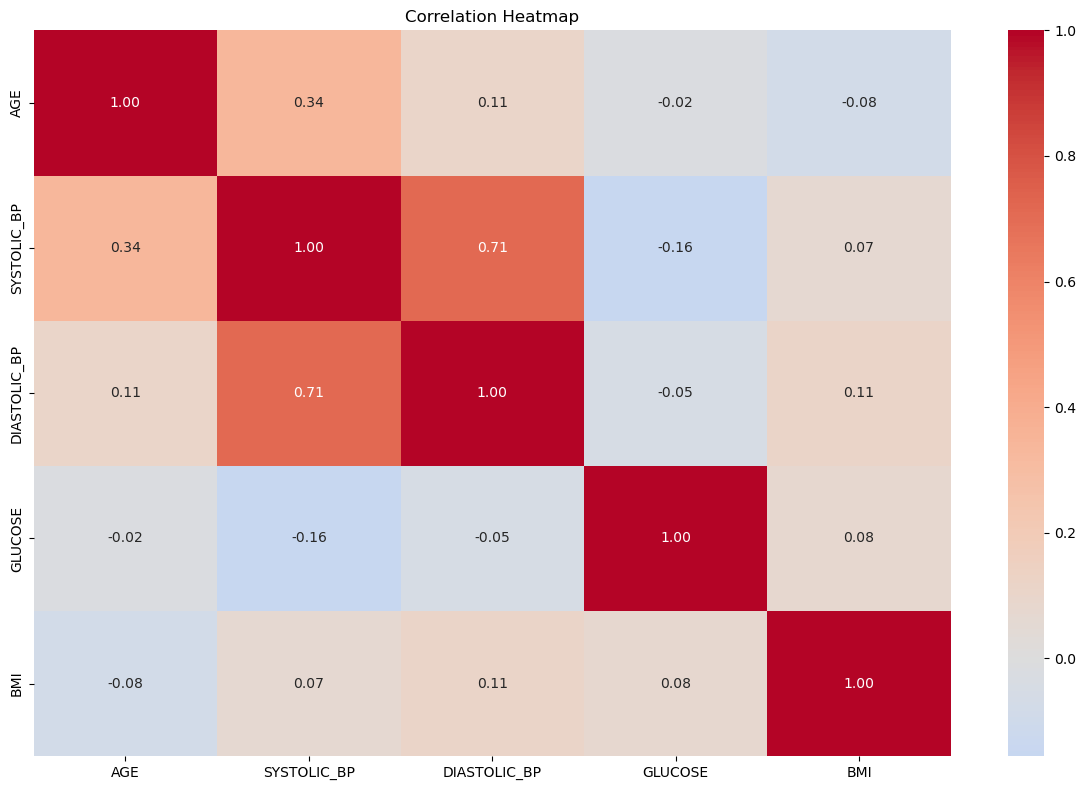

In [86]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation analysis shows a strong positive correlation between systolic and diastolic blood pressure (r = 0.71). Age also has a moderate positive correlation with systolic blood pressure (r = 0.34). The remaining variables show weak correlations, including glucose with systolic blood pressure (r = −0.16) and BMI with the other variables. Overall, no strong correlation was observed between glucose, BMI, and the other clinical features.

In [87]:
df = df.drop(columns=["GLUCOSE"])

Glucose was excluded from the feature set because its measurement requires a blood-based test, whereas this study focuses on non-invasive diabetes prediction using readily measurable clinical features.

In [88]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_cols

['AGE', 'SYSTOLIC_BP', 'DIASTOLIC_BP', 'BMI']

In [89]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

categorical_cols

['GENDER', 'DIABETIC']

In [90]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df[numerical_cols] < lower_bound) |
            (df[numerical_cols] > upper_bound)).sum()

outliers

AGE               2
SYSTOLIC_BP     149
DIASTOLIC_BP     59
BMI             148
dtype: int64

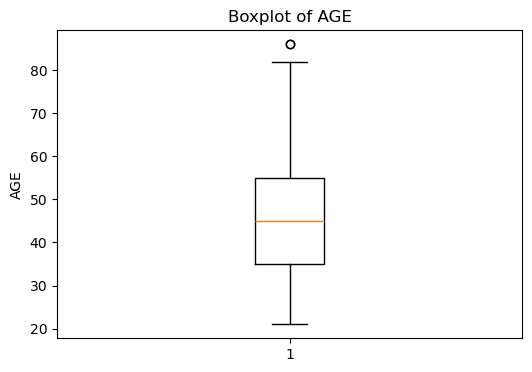

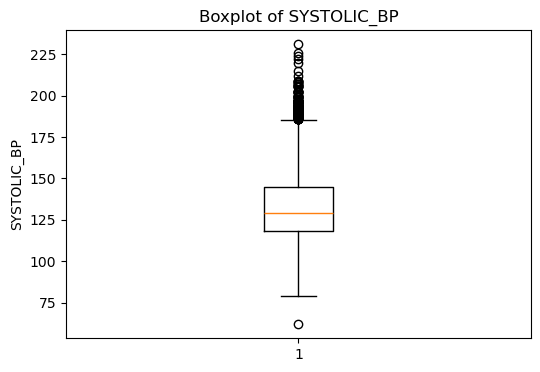

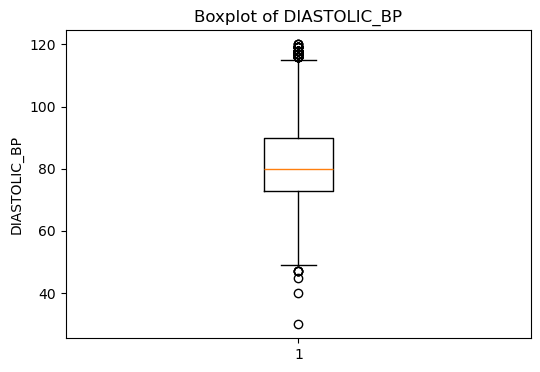

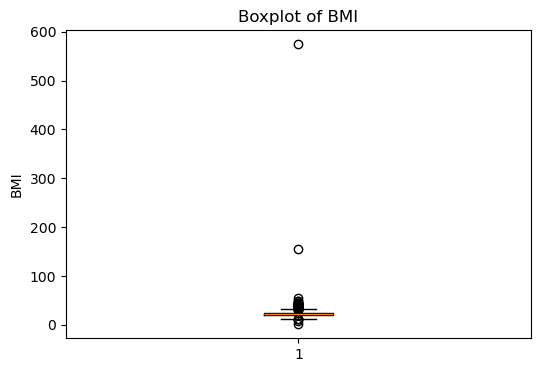

In [91]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

After examining the identified outliers, `AGE` and `DIASTOLIC_BP` values were considered within plausible ranges and were retained. However, `SYSTOLIC_BP` values above 200 mmHg and extreme `BMI` values may be considered abnormal. These values should be further checked and validated before deciding whether to remove or retain them.


In [92]:
upper_bound["SYSTOLIC_BP"]

np.float64(185.5)

In [93]:
df[df["SYSTOLIC_BP"] > upper_bound["SYSTOLIC_BP"]]["SYSTOLIC_BP"].sort_values()

1228    186
1838    186
2401    186
2147    186
3089    186
       ... 
5906    220
1463    222
2643    224
1090    226
5861    231
Name: SYSTOLIC_BP, Length: 148, dtype: int64

The `SYSTOLIC_BP` values appear unusually high, with the highest value reaching 231 mmHg. However, this value is medically possible and may represent a genuine observation. Therefore, the high values were retained rather than removed.


In [94]:
upper_bound["BMI"]

np.float64(32.18)

In [95]:
df[df["BMI"] > upper_bound["BMI"]]["BMI"].sort_values()

4493     32.190000
2283     32.200000
287      32.253334
429      32.258129
404      32.258129
           ...    
2056     47.970000
3358     48.440000
4443     54.080000
1950    155.740000
1217    574.130000
Name: BMI, Length: 143, dtype: float64

In [96]:
df[df["BMI"] > 100]["BMI"].sort_values()

1950    155.74
1217    574.13
Name: BMI, dtype: float64

In [97]:
df = df[df["BMI"] <= 100].copy()

There were some anomalies in the `BMI` column, with 143 values exceeding the upper bound identified through the outlier analysis. After further examination, a BMI value of 100 was used as a practical plausibility limit. Values exceeding this limit were flagged as anomalies and removed from the dataset.


In [98]:
df.shape

(5774, 6)